In [1]:
import tensorflow as tf


(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

print(len(X_train_mnist))
print(len(X_train_cifar))

X_train_mnist = X_train_mnist / 255.0
X_test_mnist = X_test_mnist / 255.0

X_train_cifar = X_train_cifar / 255.0
X_test_cifar = X_test_cifar / 255.0

X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

print(X_train_mnist.shape)
print(X_test_mnist.shape)

print(X_train_cifar.shape)
print(X_test_cifar.shape)

print(y_train_mnist.shape)
print(y_train_cifar.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
60000
50000
(60000, 28, 28, 1)
(10000, 28, 28, 1)
(50000, 32, 32, 3)
(10000, 32, 32, 3)
(60000,)
(50000, 1)


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU')
)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras import layers, models

In [4]:
import time

def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       epochs=20, batch_size=64, val_split=0.1):

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_split=val_split, verbose=1)
    train_time = time.time() - start

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    model_size = model.count_params()

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Training Time: {train_time:.2f}s")
    print(f"  Model Size:    {model_size:,} parameters")

    return {
        'history': history.history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'train_time': train_time,
        'model_size': model_size,
        'model': model
    }

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_results(result, X_test, y_test):

    h = result['history']
    model = result['model']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(h['loss'], label='Train Loss')
    axes[0].plot(h['val_loss'], label='Val Loss')
    axes[0].set_title(f'Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(h['accuracy'], label='Train Acc')
    axes[1].plot(h['val_accuracy'], label='Val Acc')
    axes[1].set_title(f'Accuracy: (Test: {result["test_acc"]:.4f})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    y_true = y_test.flatten()

    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [6]:
def alex_net_choosing(input_size) :
    alex_net_model = models.Sequential([
        layers.Conv2D(96, kernel_size = (3, 3), strides = (1, 1), input_shape = input_size, padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.BatchNormalization(),

        layers.Conv2D(256, kernel_size = (3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.BatchNormalization(),

        layers.Conv2D(384, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),

        layers.Conv2D(384, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),

        layers.Conv2D(256, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides = (2, 2)),

        layers.Flatten(),

        layers.Dense(1024),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(512),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(10),
        layers.Activation('softmax')
    ])

    return alex_net_model


In [7]:
alex_net_model_cifar = alex_net_choosing((32, 32, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.4301 - loss: 1.5599 - val_accuracy: 0.3740 - val_loss: 2.0877
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.5958 - loss: 1.1495 - val_accuracy: 0.5280 - val_loss: 1.3080
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.6749 - loss: 0.9479 - val_accuracy: 0.6782 - val_loss: 0.9417
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7202 - loss: 0.8259 - val_accuracy: 0.5964 - val_loss: 1.1781
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7568 - loss: 0.7206 - val_accuracy: 0.6998 - val_loss: 0.8869
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7856 - loss: 0.6411 - val_accuracy: 0.6854 - val_loss: 0.9500
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.8106 - loss: 0.5665 - val_accuracy: 0.7100 - val_loss: 0.8908
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.8301 - loss: 0.5106 - 

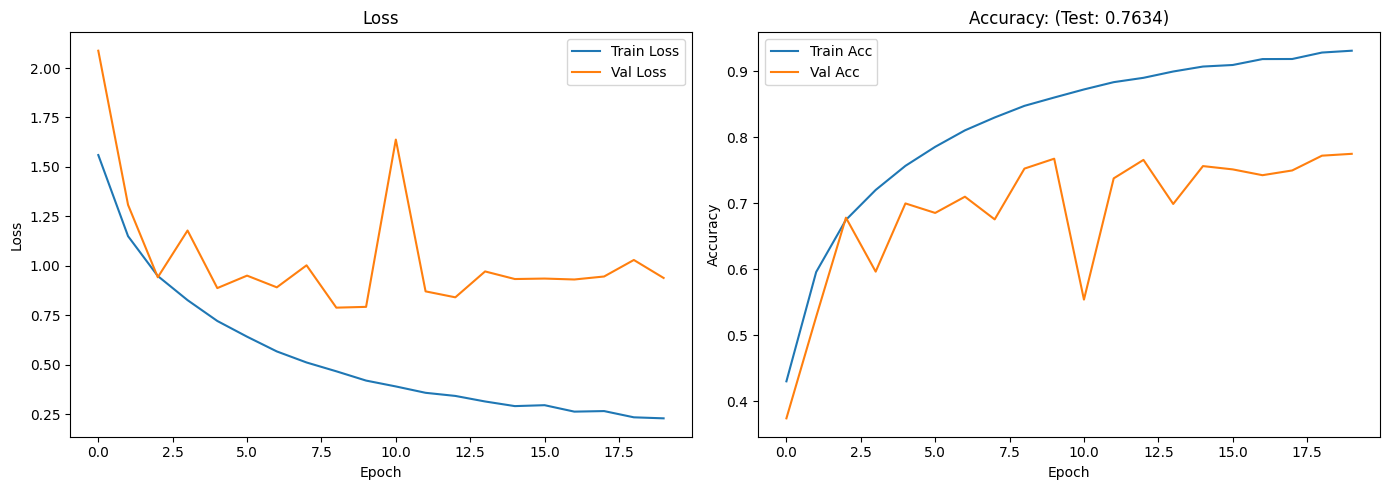

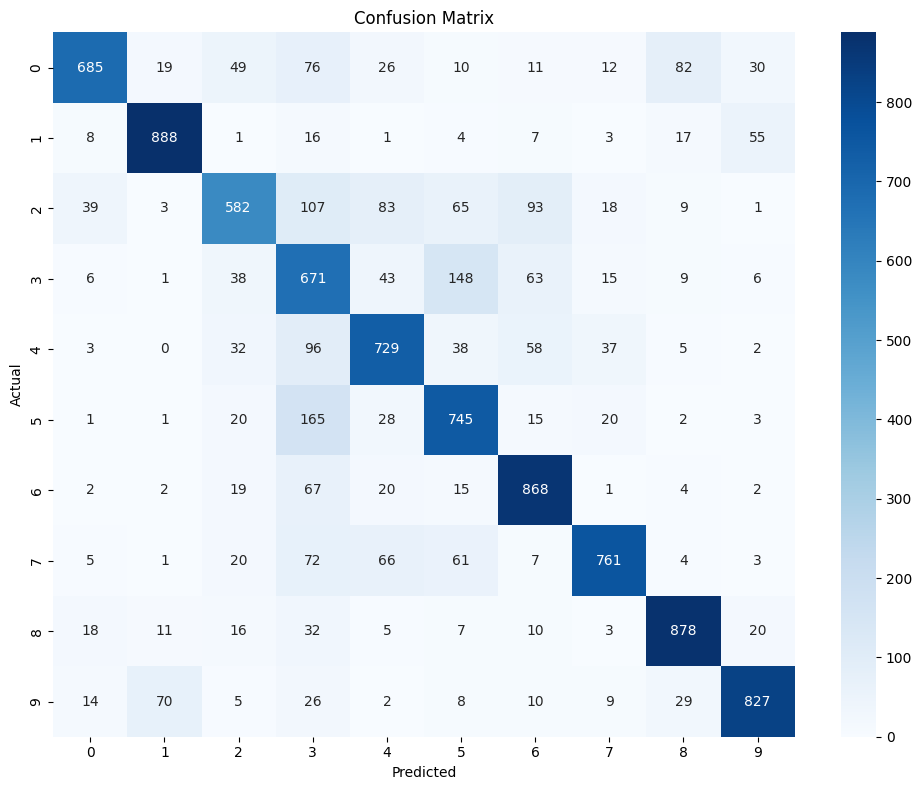

In [8]:
analytics = train_and_evaluate(alex_net_model_cifar, X_train_cifar, y_train_cifar, X_test_cifar, y_test_cifar)
plot_results(analytics, X_test_cifar, y_test_cifar)